In [58]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.losses import MeanSquaredError
from keras.optimizers import AdamW

import matplotlib.pyplot as plt

In [39]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

In [40]:
print(f"Shape of training set: {x_train.shape}")
print(f"Shape of test set: {x_test.shape}")


Shape of training set: (60000, 28, 28)
Shape of test set: (10000, 28, 28)


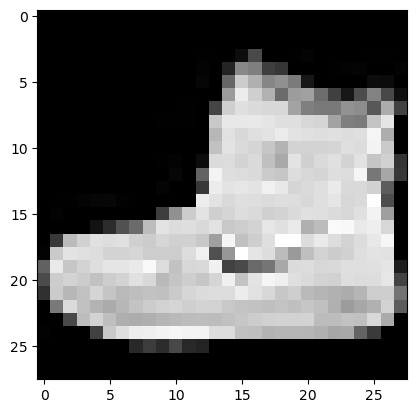

In [41]:
plt.imshow(x_train[0], cmap='gray')


In [42]:
x_train = x_train.astype(np.float32) / 255
x_test = x_test.astype(np.float32) / 255

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [43]:
x_train.shape

(60000, 28, 28, 1)

In [51]:
class AutoEncoder(keras.Model):
    def __init__(self, latent_dim, input_shape):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_shape = input_shape

        self.encoder = Sequential(
            [
                Flatten(),
                Dense(latent_dim, activation='relu')
            ]
        )

        self.decoder = Sequential(
            [
                Dense(int(np.prod(input_shape)), activation='sigmoid'),
                keras.layers.Reshape(input_shape)
            ]
        )

    def call(self, inputs):
        latent = self.encoder(inputs)
        output = self.decoder(latent)

        return output

In [52]:
model = AutoEncoder(latent_dim=10, input_shape=(28, 28, 1))

In [53]:
x = tf.expand_dims(x_train[0], axis=0)
print(x.shape)
# (1, 28, 28, 1)

y = model(x)
y
# (1, 28, 28, 1)

(1, 28, 28, 1)


<tf.Tensor: shape=(1, 28, 28, 1), dtype=float32, numpy=
array([[[[0.4976802 ],
         [0.49878138],
         [0.5228797 ],
         [0.49014097],
         [0.4535954 ],
         [0.4684928 ],
         [0.5369363 ],
         [0.47937974],
         [0.48844165],
         [0.4909326 ],
         [0.5215493 ],
         [0.5032364 ],
         [0.50160694],
         [0.504804  ],
         [0.48477003],
         [0.51330215],
         [0.5372933 ],
         [0.5061637 ],
         [0.50905   ],
         [0.47750035],
         [0.4951612 ],
         [0.52586395],
         [0.4968227 ],
         [0.5397213 ],
         [0.4719772 ],
         [0.5020859 ],
         [0.5114084 ],
         [0.4864513 ]],

        [[0.46228993],
         [0.49175447],
         [0.48593354],
         [0.4967565 ],
         [0.53522265],
         [0.47807276],
         [0.4764275 ],
         [0.5164575 ],
         [0.5312413 ],
         [0.4944635 ],
         [0.507769  ],
         [0.5351352 ],
         [0.4823733 ],

In [57]:
model.encoder.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (1, 784)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (1, 10)                │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.decoder.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (1, 784)               │         8,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (1, 28, 28, 1)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,624 (33.69 KB)

 Trainable params: 8,624 (33.69 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(optimizer=AdamW(learning_rate=0.001),
              loss=MeanSquaredError,
              metrics=['mae'])

In [61]:
history = model.fit(x_train, x_train, validation_split=0.02, epochs=20, batch_size=32)

Epoch 1/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0386 - mae: 0.1277 - val_loss: 0.0256 - val_mae: 0.0978
Epoch 2/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0233 - mae: 0.0920 - val_loss: 0.0225 - val_mae: 0.0894
Epoch 3/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0219 - mae: 0.0879 - val_loss: 0.0220 - val_mae: 0.0877
Epoch 4/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0215 - mae: 0.0869 - val_loss: 0.0218 - val_mae: 0.0873
Epoch 5/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0214 - mae: 0.0865 - val_loss: 0.0216 - val_mae: 0.0869
Epoch 6/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0213 - mae: 0.0862 - val_loss: 0.0215 - val_mae: 0.0869
Epoch 7/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0212 - mae: 0.0861 - val_loss: 0.0215 - val_mae: 0.0867
Epoch 8/20
1838/1838 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0212 - mae: 0.0860 - val_loss: 0.0215 - val_mae: 0.0866
Epoch 9/20
1838/1838 ━━━━━━━━━━━━━━━━━━━

In [69]:
latent = model.encoder(x_test[0].reshape(-1, 28, 28, 1))

In [70]:
latent.shape

TensorShape([1, 10])

In [72]:
output = model.decoder(latent)

Text(0.5, 1.0, 'Reconstracted Image')

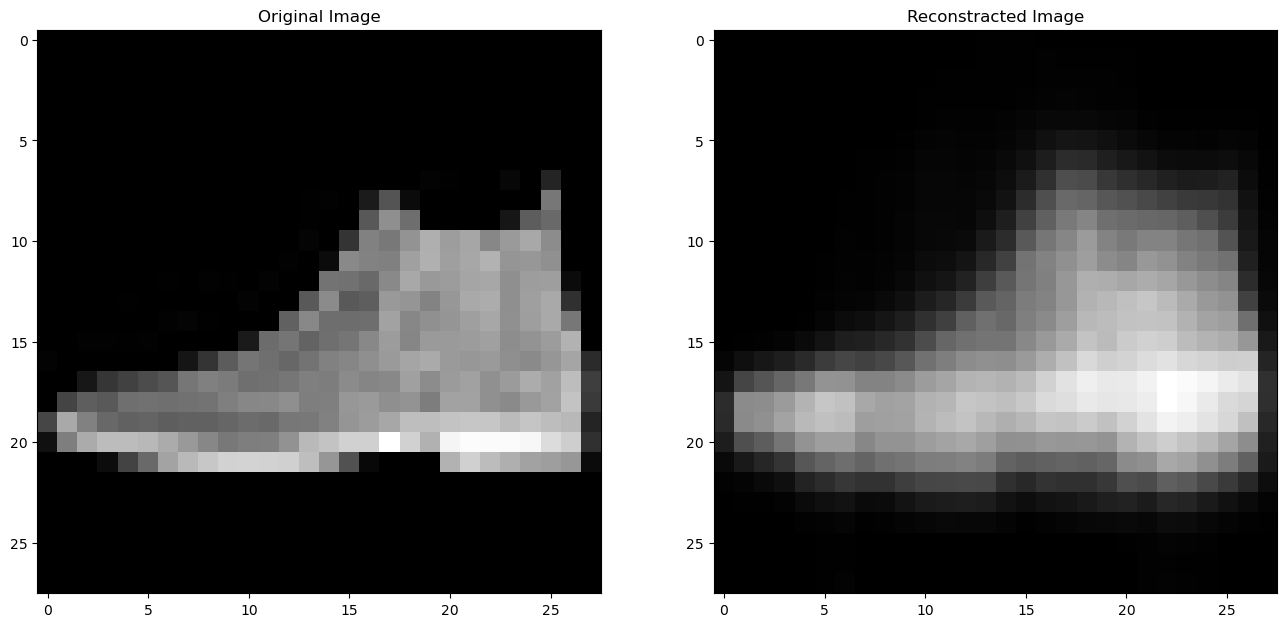

In [74]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1); plt.imshow(x_test[0], cmap='gray'); plt.title("Original Image")
plt.subplot(1, 2, 2); plt.imshow(output[0], cmap='gray'); plt.title("Reconstracted Image")